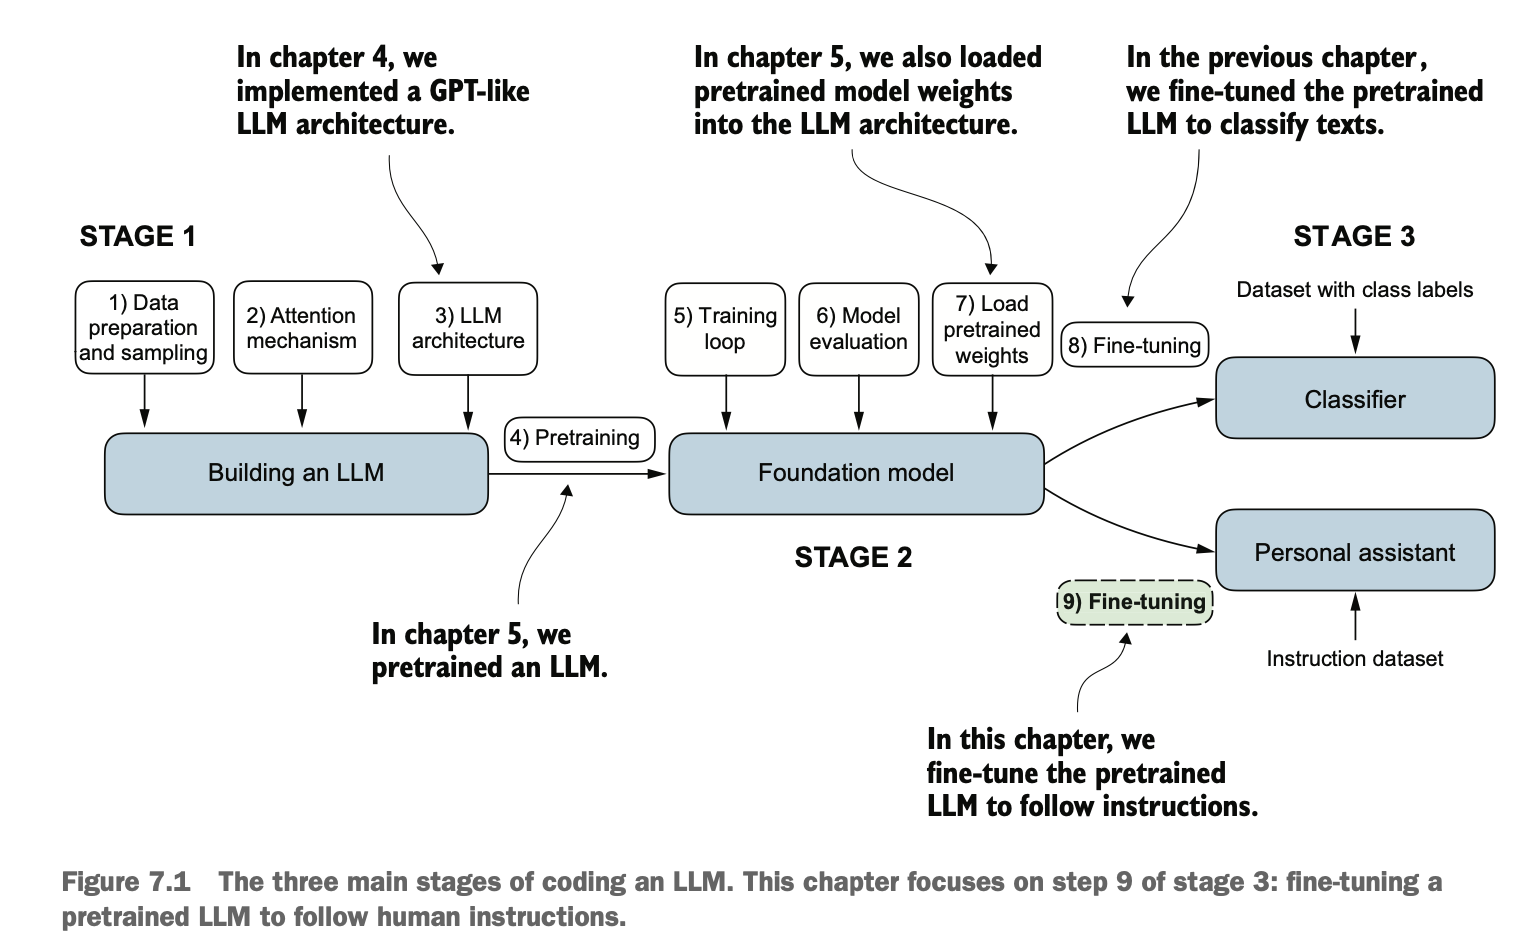

**Introduction to instruction fine_tuning**

A basic AI learns by predicting the next word in text. But this makes it only good at completing text — not following commands like "Fix my grammar".
Instruction fine-tuning is extra training that teaches the AI to actually follow instructions and give useful answers.English Summary
A pretrained LLM learns to complete text word by word, but it struggles to follow specific instructions like fixing grammar or changing sentence structure.
Instruction fine-tuning is extra training that teaches the LLM to properly understand and follow instructions to give useful responses.

The process has 3 main stages:

Prepare the dataset — collect instructions with correct responses

Fine-tune the model — train it on that dataset

Result — LLM can now follow instructions
properly


**Roman Urdu Summary**

Ek pretrained LLM sirf text complete karna jaanta hai — yani agle words predict karta hai. Lekin yeh specific instructions follow nahi kar sakta, jaise:

"Grammar theek karo"
"Passive voice mein badlo"

Instruction fine-tuning ek extra training hai jisme LLM ko sikhaya jata hai ke instructions ko samjhe aur sahi jawab de.

3 main steps hain:

Dataset tayyar karo — instructions aur sahi jawab ikattha karo
Model train karo — us data pe
Natija — LLM ab instructions achhi tarah follow kar sakta hai ✅

The key steps are:

Prepare a good dataset of instructions + correct responses

Train the AI on that dataset

Now it can properly respond to commands!



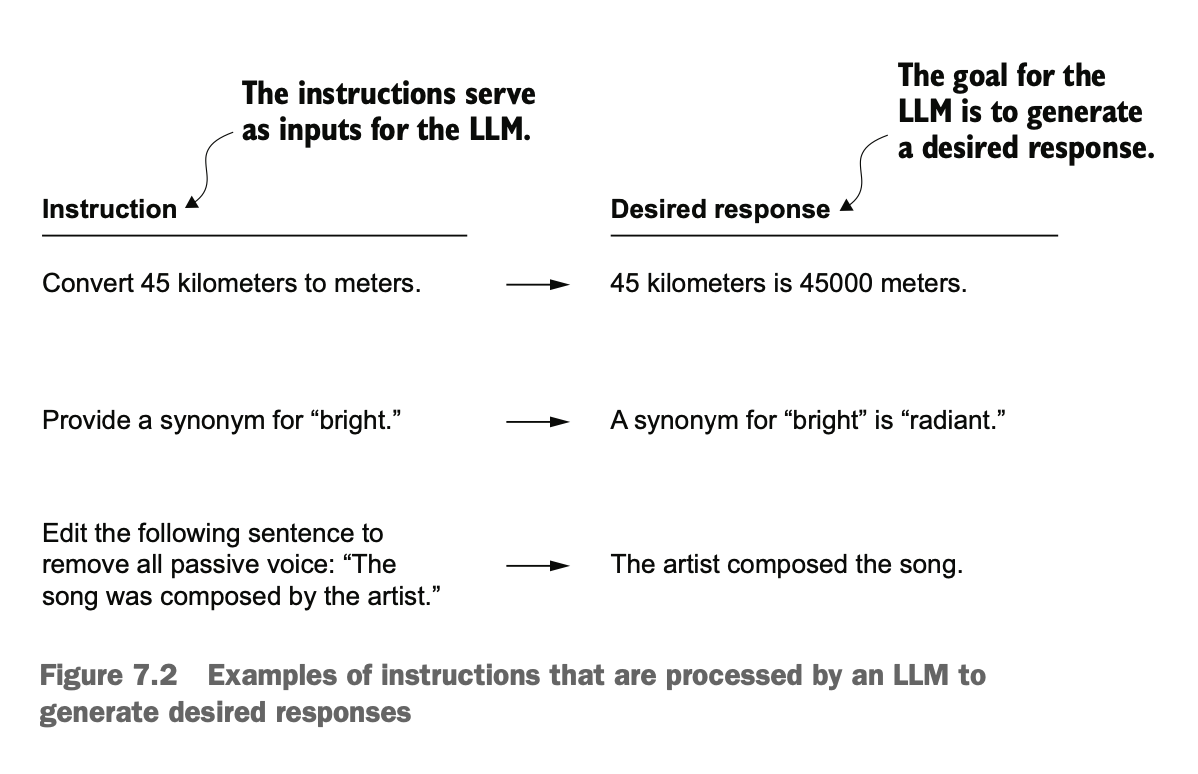


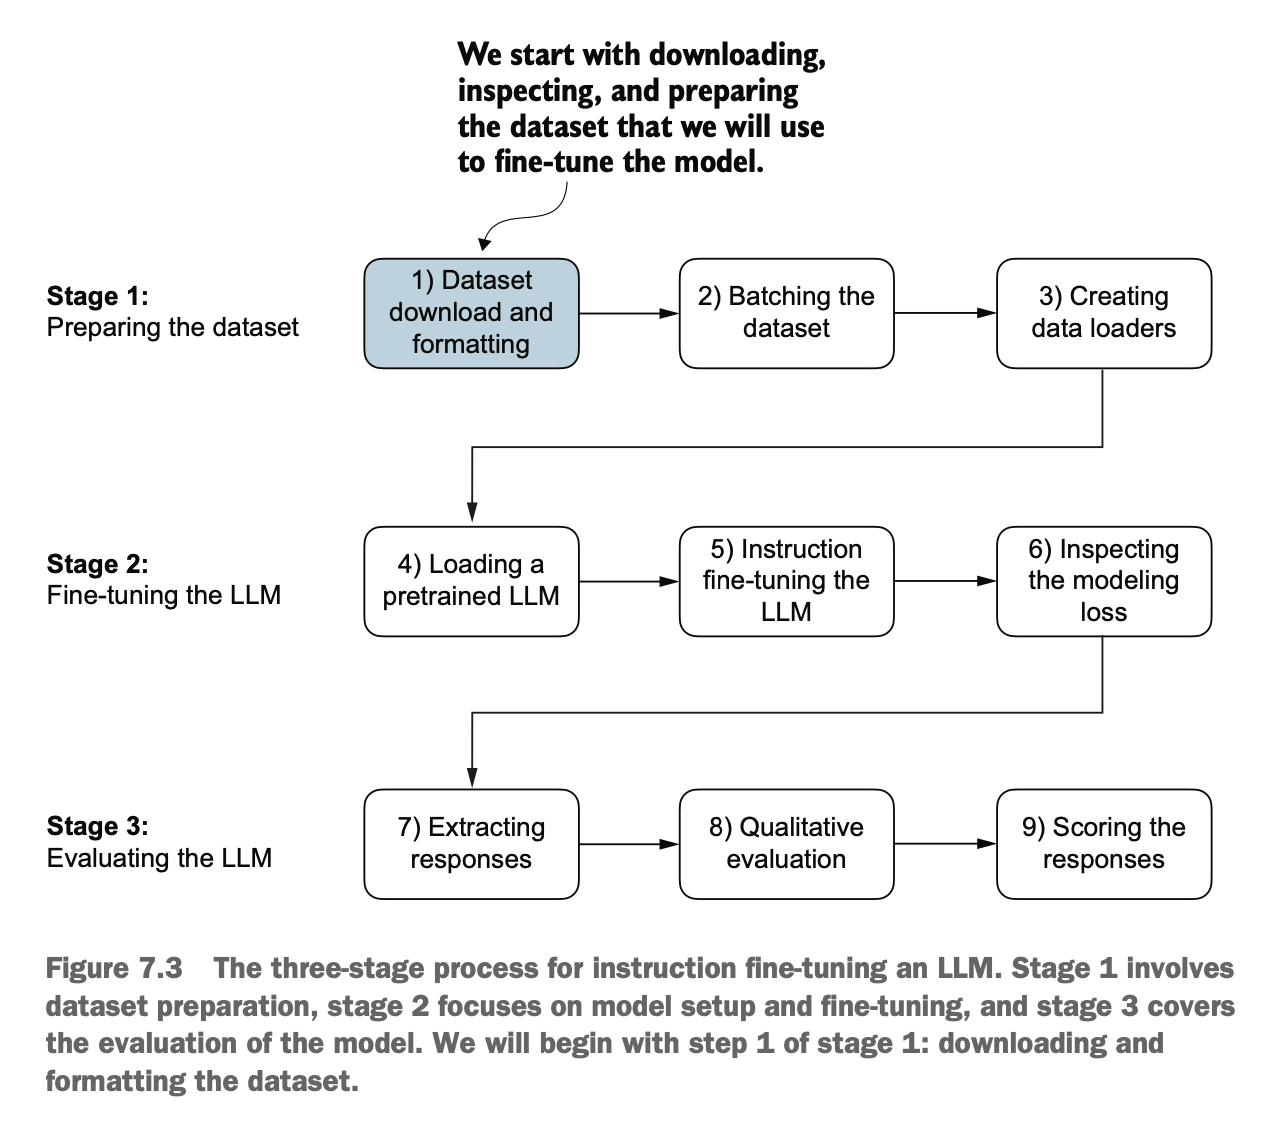

**Preparing a dataset for supervised instruction fine-tuning**

To train an LLM to follow instructions, we first need a dataset of instruction-response pairs.
Key points:

The dataset has 1,100 instruction-response pairs

It is a small file (204 KB) in JSON format

JSON is like a Python dictionary — easy for both humans and machines to read

The dataset is downloaded and formatted before fine-tuning begins

JSON was chosen because it is simple, readable, and widely used for storing structured data.

In [1]:
# data download and load

import json
import os
import urllib



In [23]:
def download_and_load_file(file_path , url): #-> we ctrate the function and pass 2 parameters in the function
  if not os.path.exists(file_path):# -> condition if file is not exist in the computer
    with urllib.request.urlopen(url) as response:# -> we will send the response throug urllib and through  urlopen we will open the link
      text_data = response.read().decode("utf-8")# -> that response save in the variable
    with open(file_path , "w" ) as file:# -> we create the file where we will store the respnse
      file.write(text_data)# -> here we will write the response
  else:
    with open(file_path , "r",encoding = "utf-8" ) as file:
      text_data = file.read()


    with open (file_path , "r" , encoding = "utf-8") as file:

       text_data=json.load(file)
  return text_data

file_path = "instruction_dataset.json"
url = ("https://raw.githubusercontent.com/rasbt/LLMs-from-scratch"
"/main/ch07/01_main-chapter-code/instruction-data.json" )

data = download_and_load_file(file_path , url)

print("number of entries -> : ",len(data))
print("ahmad")


number of entries -> :  1100
ahmad


In [18]:
print("examples entry",data[50])

examples entry {'instruction': 'Identify the correct spelling of the following word.', 'input': 'Ocassion', 'output': "The correct spelling is 'Occasion.'"}


In [19]:
print("another entries -> ",data[999])

another entries ->  {'instruction': "What is an antonym of 'complicated'?", 'input': '', 'output': "An antonym of 'complicated' is 'simple'."}


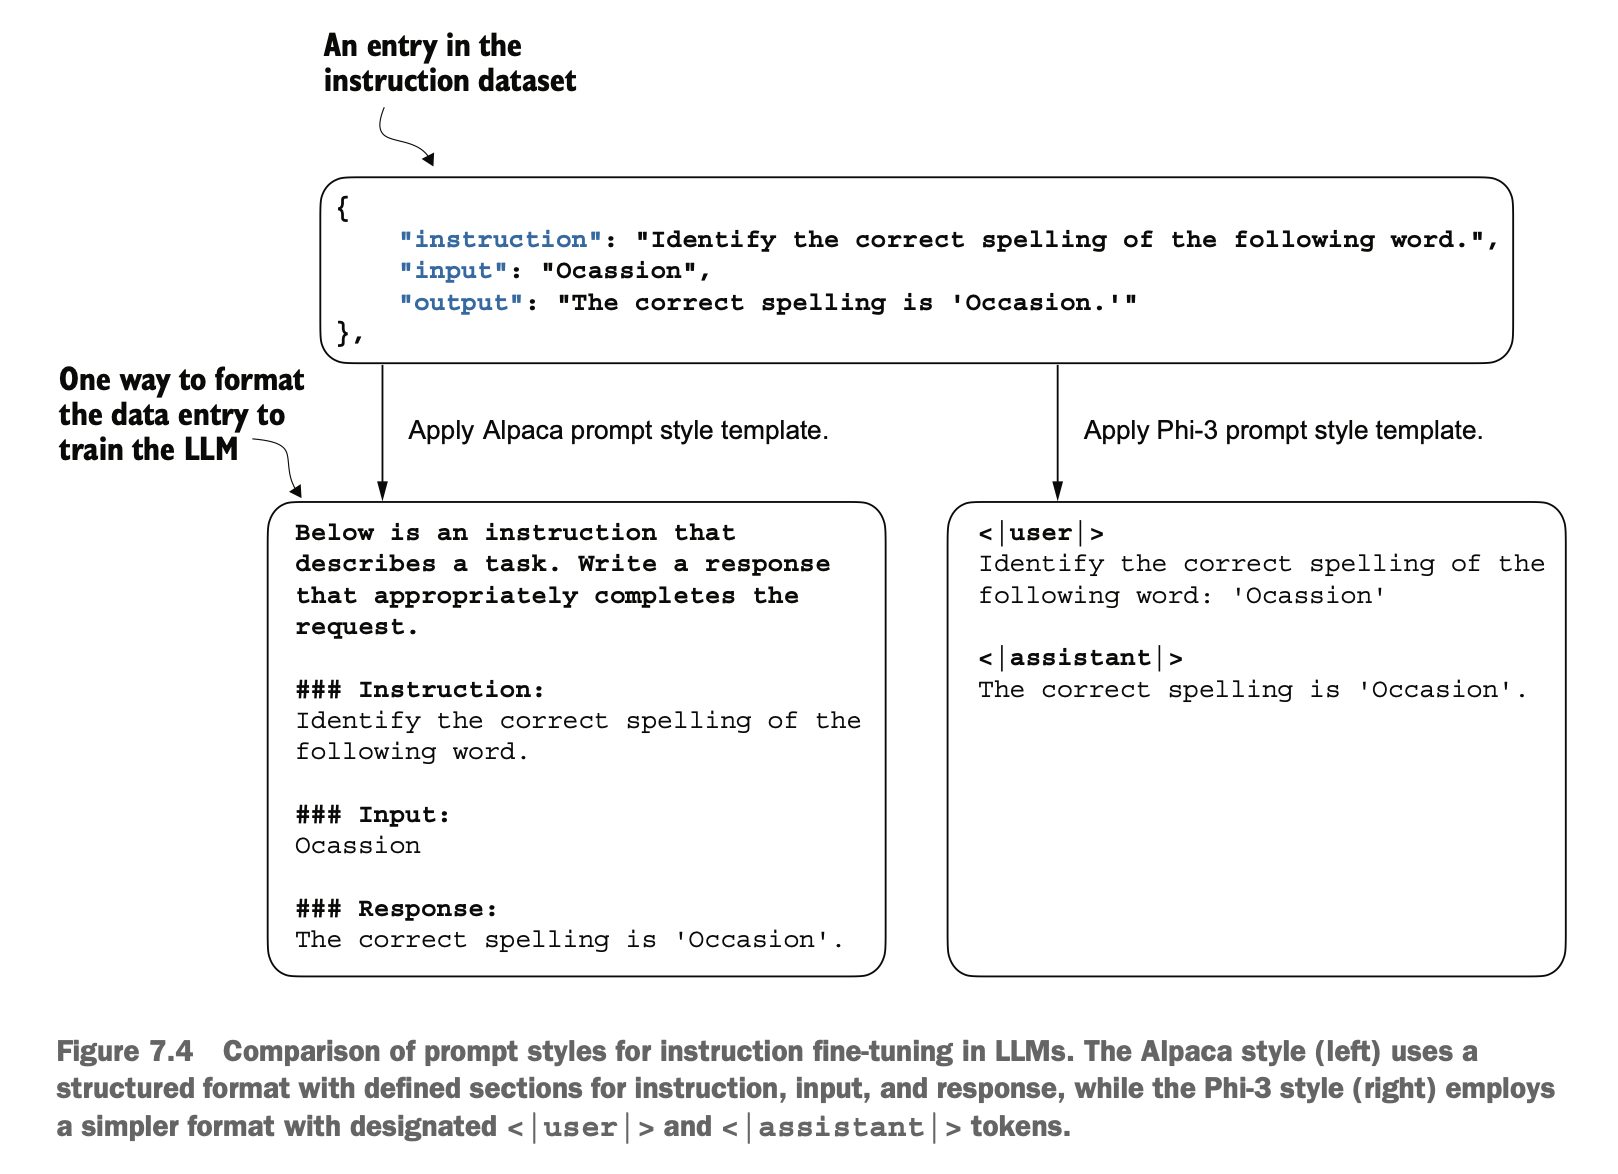

example formats, often referred to as prompt styles, used in the training of notable LLMs such as Alpaca and Phi-3.

Alpaca was one of the early LLMs to publicly detail its instruction fine-tuning pro- cess. Phi-3, developed by Microsoft, is included to demonstrate the diversity in prompt styles. The rest of this chapter uses the Alpaca prompt style since it is one of the most popular ones, largely because it helped define the original approach to fine-tuning.






**Let’s define a format_input function that we can use to convert the entries in the data list into the Alpaca-style input format.**

In [56]:
#Implementing the prompt formatting function
def formate_input(entry):
  instruction_input = (

                      f"Below is an instruction that describes a task. "
   f"Write a response that appropriately completes the request."
                       f"\n\n### instruction :{entry["instruction"]}"
  )
  input = (

           f"\n\n### input : {entry ["input"]}"

           if entry["input"]
           else ""

  )
  return instruction_input + input



In [57]:
input = formate_input(data[50])
desire_output = f"\n\n### output ,{data[50]["output"]}"
print(input)
print(desire_output)






Below is an instruction that describes a task. Write a response that appropriately completes the request.

### instruction :Identify the correct spelling of the following word.

### input : Ocassion


### output ,The correct spelling is 'Occasion.'


In [59]:
input = formate_input(data[999])
desire_output = f"\n\n### output ,{data[999]["output"]}"
print(input)
print(desire_output)


Below is an instruction that describes a task. Write a response that appropriately completes the request.

### instruction :What is an antonym of 'complicated'?


### output ,An antonym of 'complicated' is 'simple'.


In [63]:
# Partitioning the dataset


train_portion = int(len(data) * 0.85)
test_portion = int(len(data) * 0.1)
val_portion = len(data) - train_portion - test_portion
train_data = data[:train_portion]
test_data = data[train_portion:train_portion + test_portion]
val_data = data[train_portion + test_portion:]
print("Training set length:", len(train_data))
print("Validation set length:", len(val_data))
print("Test set length:", len(test_data))


Training set length: 935
Validation set length: 55
Test set length: 110
